### Exploratory Data Analysis (EDA)

## 1. Objective

This notebook performs Exploratory Data Analysis (EDA) on the Telco Customer Churn dataset. The goal is to:

- Understand the distribution of churned vs. retained customers
- Explore key demographic and service-related features
- Identify patterns and relationships that may influence churn
- Generate visual insights to guide feature engineering and modeling



2. Churn Distribution

C:\Users\franc\AppData\Local\Temp\ipykernel_14068\535867339.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


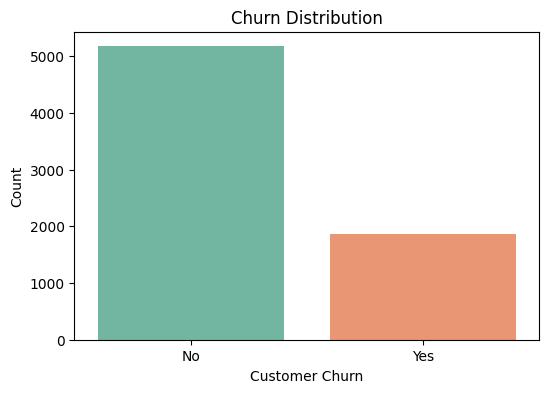

📌 Churn Rate:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/processed/telco_clean_base.csv")

# Plot churn distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title("Churn Distribution")
plt.xlabel("Customer Churn")
plt.ylabel("Count")
plt.show()

# Percentage
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print("📌 Churn Rate:\n", churn_rate)



Roughly **27% of customers have churned**, indicating a moderate imbalance. This will be important to consider during model training (e.g., stratified sampling or class weighting).


3. Univariate Analysis — Categorical Features

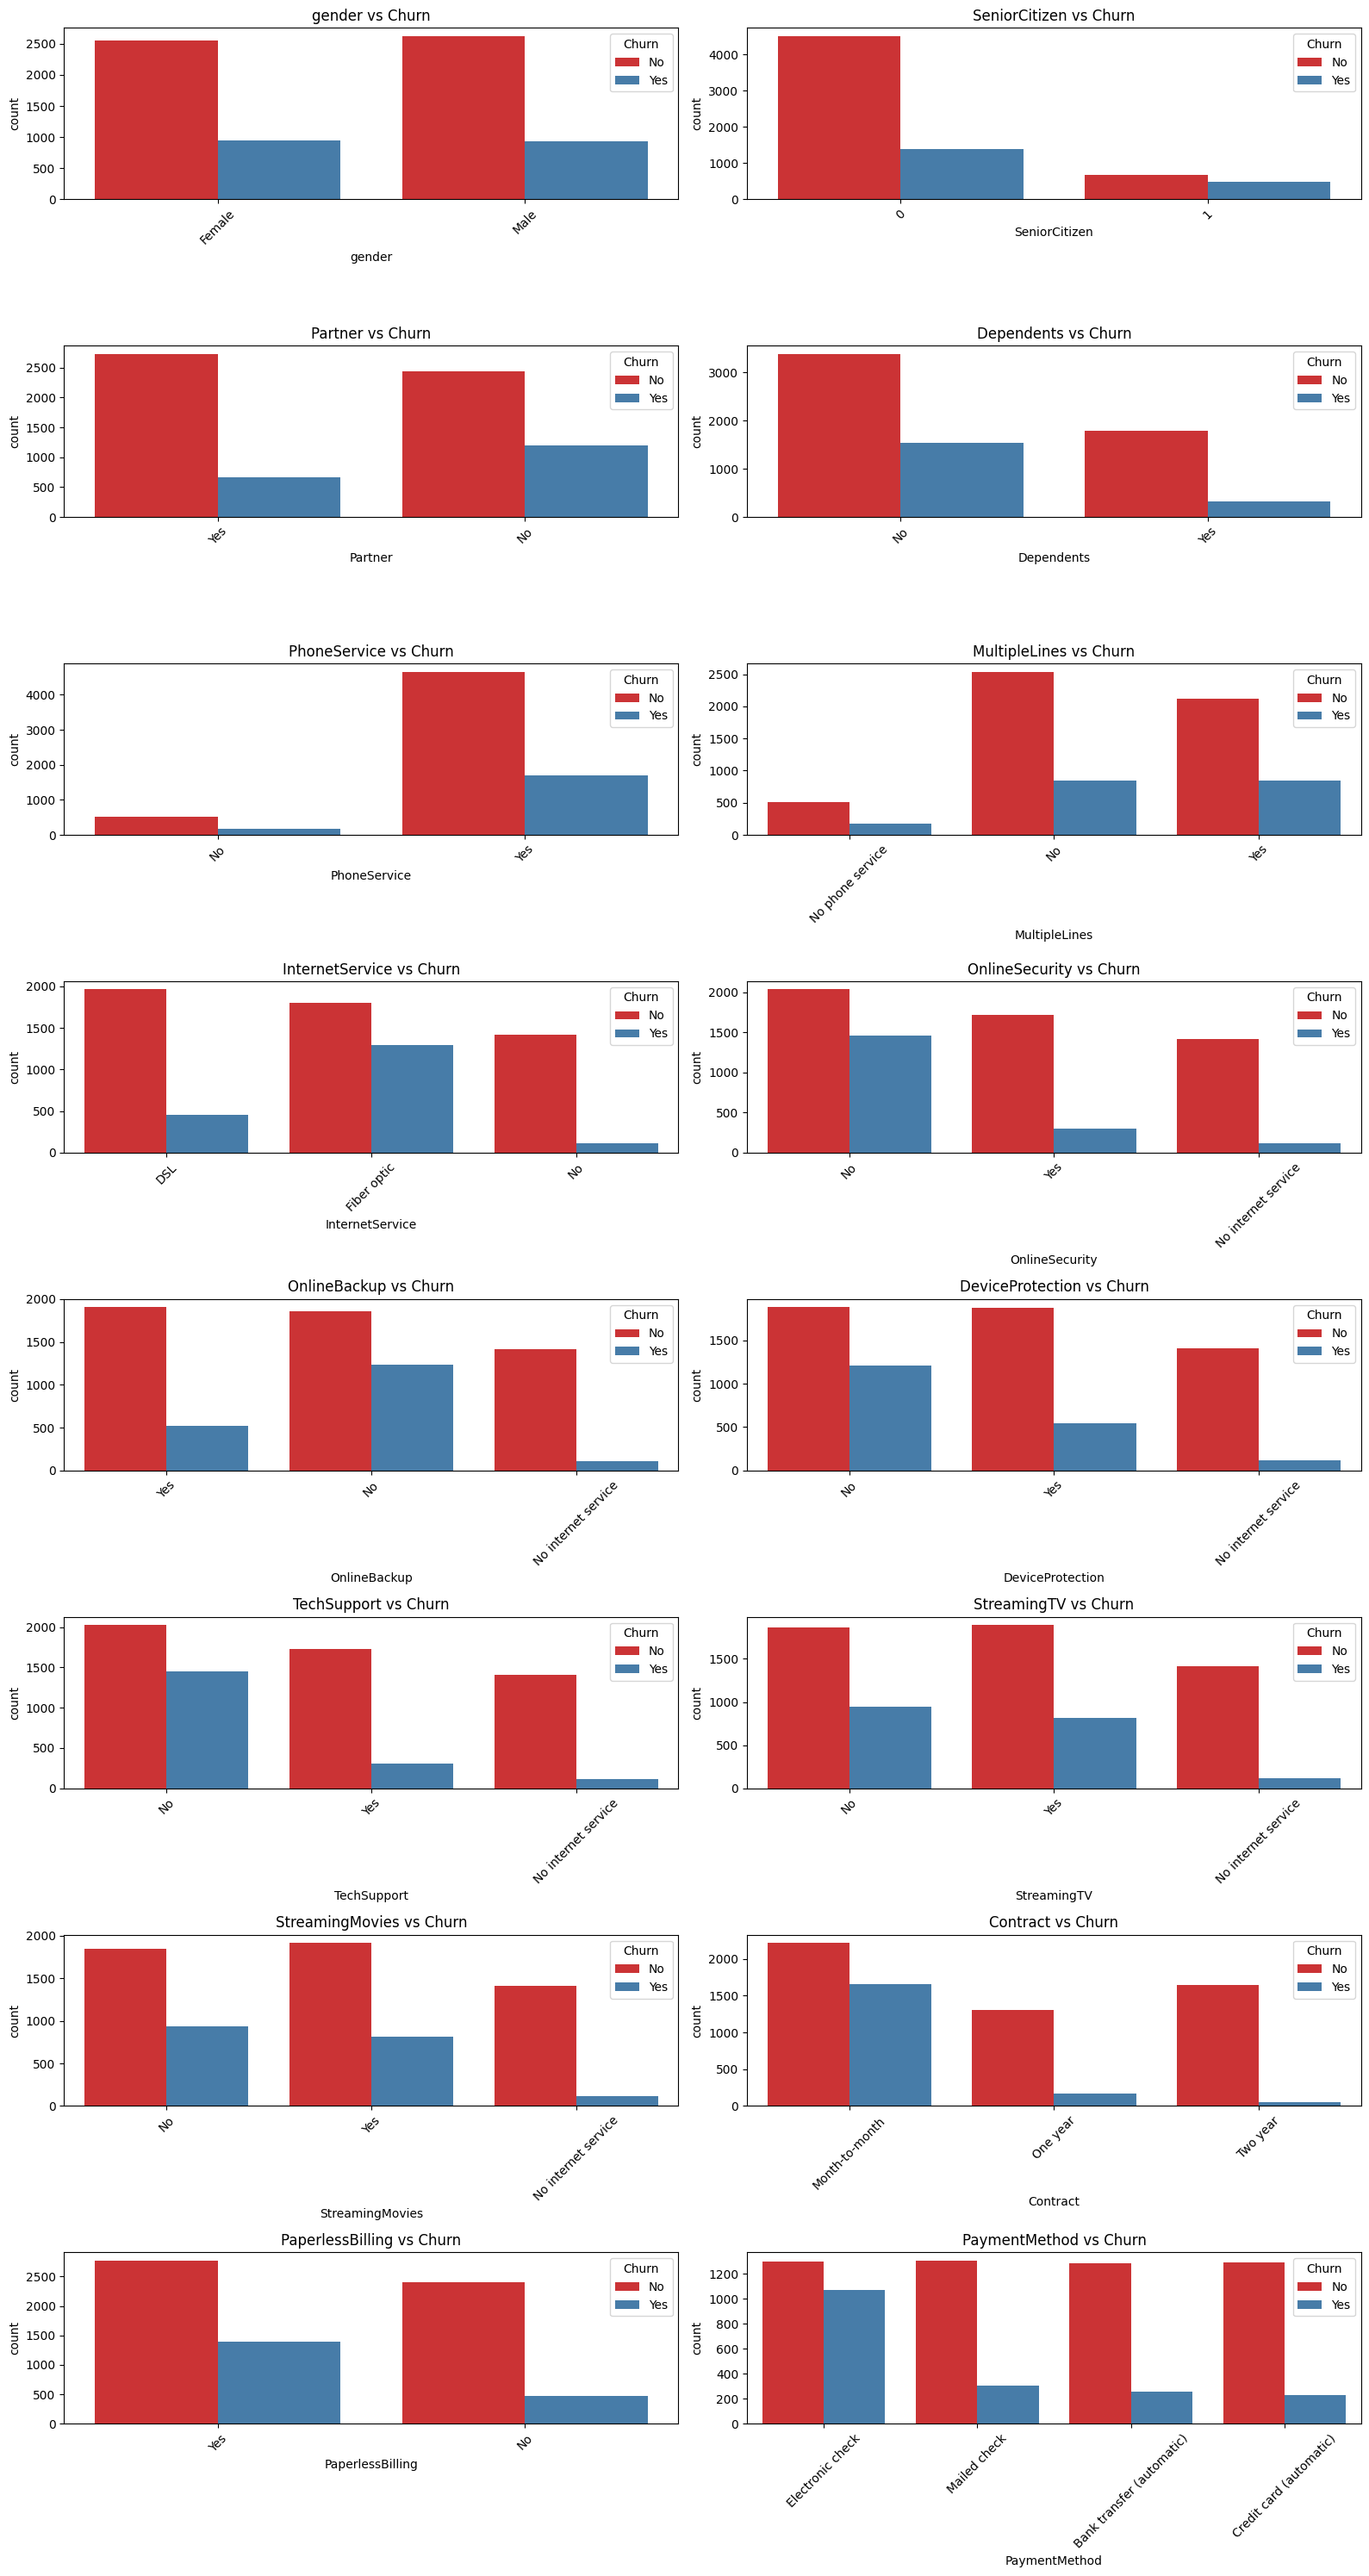

In [3]:
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                    'PhoneService', 'MultipleLines', 'InternetService', 
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

plt.figure(figsize=(16, 30))
for i, col in enumerate(categorical_cols):
    plt.subplot(8, 2, i+1)
    sns.countplot(data=df, x=col, hue='Churn', palette='Set1')
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 

- **Contract Type**: Customers with **month-to-month contracts churn significantly more** than those on one- or two-year contracts.
- **Tech Support & Online Security**: Lack of these services correlates with higher churn.
- **Senior Citizens**: Slightly more likely to churn.
- **Paperless Billing**: Customers using paperless billing churn more — possibly due to digital-only engagement.


4. Univariate Analysis — Numerical Features

C:\Users\franc\AppData\Local\Temp\ipykernel_14068\2170714263.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


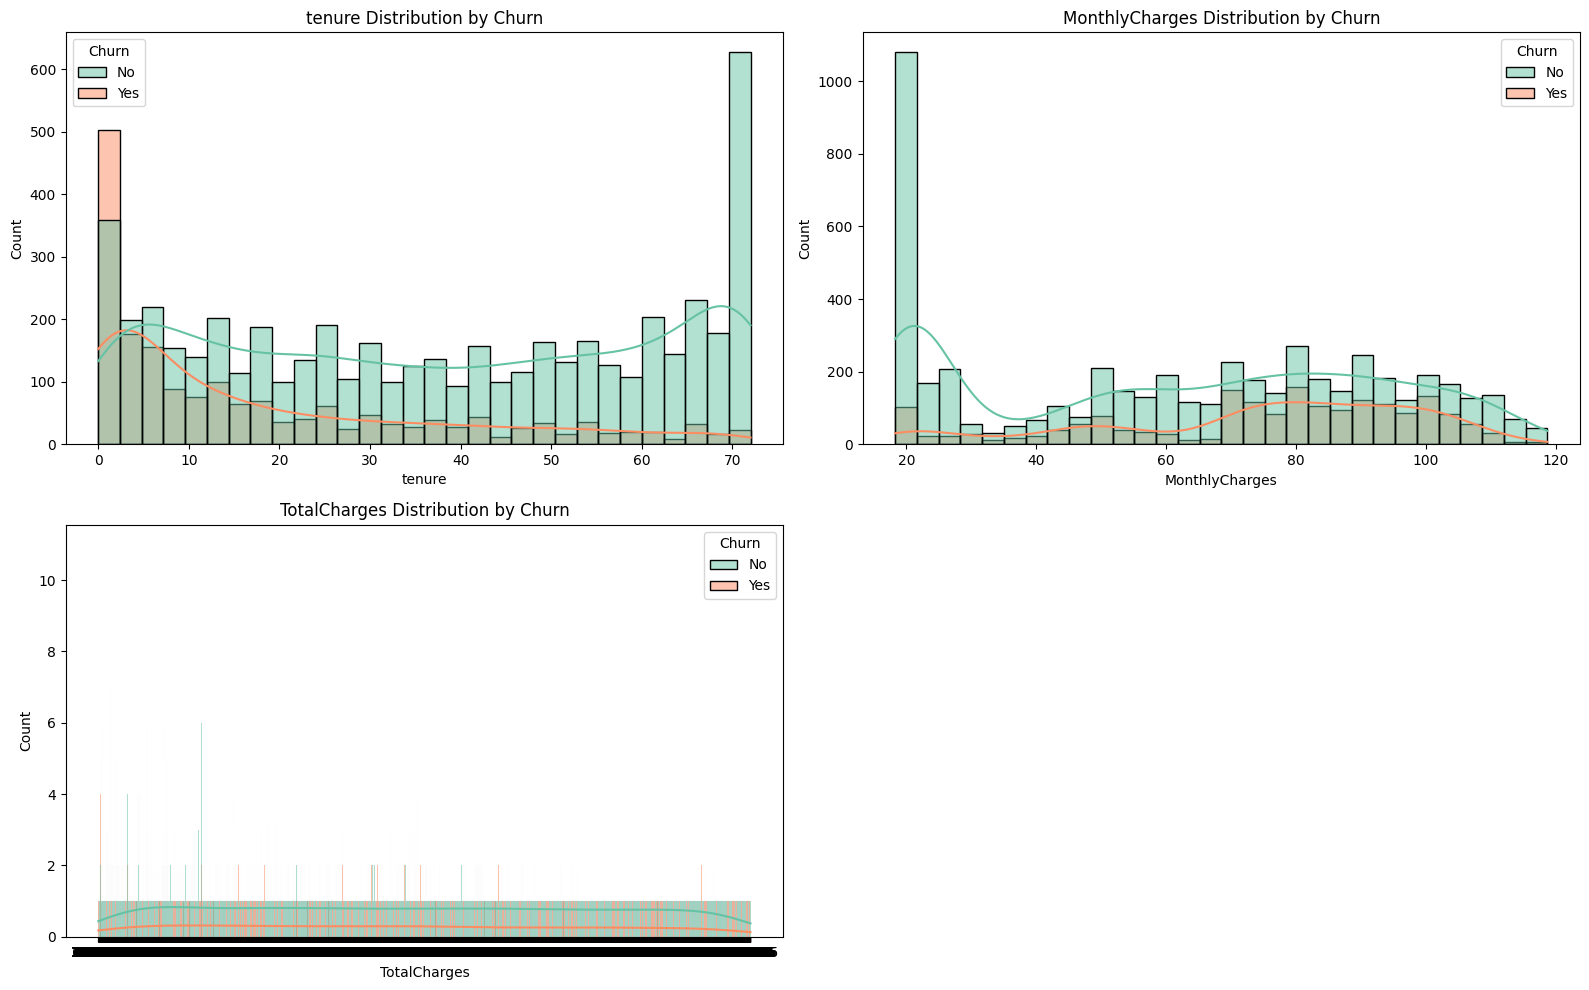

In [4]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i+1)
    sns.histplot(data=df, x=col, hue='Churn', kde=True, palette='Set2', bins=30)
    plt.title(f"{col} Distribution by Churn")
plt.tight_layout()
plt.show()




- **Tenure**: Customers with **shorter tenure are more likely to churn** — a strong early churn signal.
- **Monthly Charges**: Higher charges are associated with increased churn.
- **Total Charges**: Lower total charges (i.e., newer customers) show higher churn — consistent with tenure.


5. Correlation Heatmap

In [6]:
df.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [11]:
# Encode churn as binary
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

In [12]:
# Select numeric columns
corr_matrix = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()

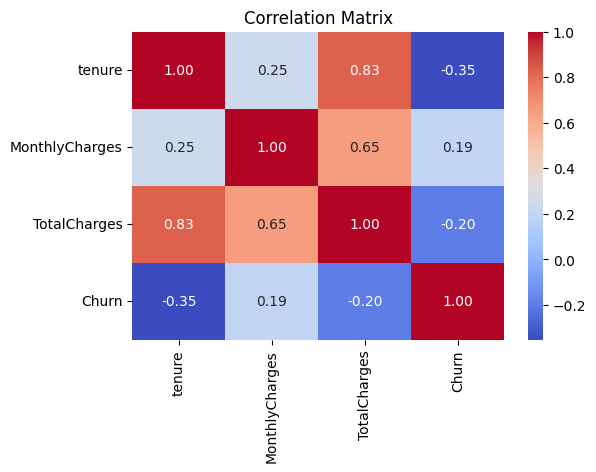

In [13]:
# Plot
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()



- **Tenure** has a **strong negative correlation** with churn (−0.35): the longer a customer stays, the less likely they are to churn.
- **Monthly Charges** show a **positive correlation** with churn (0.19): higher bills may drive dissatisfaction.


6. Key Takeaways



- Customers with **short tenure**, **month-to-month contracts**, and **no tech support or online security** are more likely to churn.
- **Senior citizens**, **paperless billing users**, and those with **higher monthly charges** also show elevated churn risk.
- These insights will guide feature engineering and model selection in the next phase.


